# Cinematica inversa basica - robo snake

Este notebook continua o estudo da cinematica do robo snake.

Na **cinematica direta**, entramos com os angulos das juntas e encontramos a posicao da ponta.

Na **cinematica inversa**, fazemos o contrario:

1. definimos onde queremos que a ponta chegue;
2. calculamos quais angulos das juntas aproximam a ponta desse alvo.

Como o robo possui 9 juntas e a ponta e definida por apenas duas coordenadas `(x, y)`, existem muitas solucoes possiveis. Por isso, usaremos um metodo numerico simples baseado no Jacobiano.


## Foto de referencia

A prancha tecnica abaixo contem as cotas usadas como referencia.

![Prancha tecnica de referencia](imagens/prancha_tecnica_referencia.png)

Neste notebook, a origem `(0, 0)` esta no ponto inferior da montagem. O alvo usado como exemplo e o ponto superior:

`alvo = [-62,39 mm, 115,51 mm]`


## Imagens de apoio da cinematica inversa

As imagens abaixo mostram visualmente as etapas principais da cinematica inversa.

**1. Alvo definido para a ponta**

![Alvo da cinematica inversa](imagens/cinematica_inversa_alvo.png)

**2. Pose inicial antes do metodo iterativo**

![Pose inicial da cinematica inversa](imagens/cinematica_inversa_pose_inicial.png)

**3. Solucao final encontrada**

![Solucao da cinematica inversa](imagens/cinematica_inversa_solucao.png)

**4. Convergencia do erro**

![Convergencia do erro da cinematica inversa](imagens/cinematica_inversa_convergencia.png)


## Importando bibliotecas

In [1]:
import matplotlib.pyplot as plt
import numpy as np


## 1. Dados do robo

O robo possui:

- 3 modulos;
- 3 juntas por modulo;
- 9 juntas no total;
- distancia centro-centro entre juntas de `15,17 mm`.


In [2]:
n_modulos = 3
juntas_por_modulo = 3
n_juntas = n_modulos * juntas_por_modulo

L_mm = 15.17
L = L_mm / 1000

print("Numero de juntas:", n_juntas)
print("Comprimento entre juntas:", L_mm, "mm")


Numero de juntas: 9
Comprimento entre juntas: 15.17 mm


## 2. Funcao de cinematica direta

A cinematica inversa depende da cinematica direta.

A cada tentativa de angulos, calculamos onde a ponta ficou.


In [3]:
def cinematica_direta(q_graus):
    q = np.deg2rad(q_graus)
    phi = np.cumsum(q)

    dx = L * np.cos(phi)
    dy = L * np.sin(phi)

    x = np.concatenate([[0], np.cumsum(dx)])
    y = np.concatenate([[0], np.cumsum(dy)])

    return np.column_stack([x, y])


## 3. Definindo o alvo

Queremos que a ponta do robo chegue no ponto superior da montagem.

Como a origem esta no ponto inferior:

`x = -62,39 mm`

`y = 115,51 mm`


In [4]:
alvo_mm = np.array([-62.39, 115.51])
alvo = alvo_mm / 1000

print("Alvo em mm:", alvo_mm)
print("Alvo em m:", alvo)


Alvo em mm: [-62.39 115.51]
Alvo em m: [-0.06239  0.11551]


## 4. Chute inicial

Como a cinematica inversa e numerica, precisamos comecar com uma estimativa inicial dos angulos.

Aqui usamos uma configuracao quase vertical como chute inicial, porque o alvo esta acima da origem.


In [5]:
q_inicial_graus = np.array([
    90, 0, 0,
     0, 0, 0,
     0, 0, 0,
], dtype=float)

pos_inicial = cinematica_direta(q_inicial_graus)
print("Ponta inicial [mm]:", np.round(pos_inicial[-1] * 1000, 2))


Ponta inicial [mm]: [  0.   136.53]


## 5. Jacobiano da ponta

O Jacobiano mostra como pequenas mudancas nos angulos alteram a posicao da ponta.

Para o robo planar:

`dx = J * dtheta`

Como temos 9 juntas e apenas 2 coordenadas, o Jacobiano tem dimensao `2 x 9`.


In [6]:
def jacobiano_ponta(q_rad):
    phi = np.cumsum(q_rad)
    J = np.zeros((2, len(q_rad)))

    for j in range(len(q_rad)):
        J[0, j] = -L * np.sum(np.sin(phi[j:]))
        J[1, j] =  L * np.sum(np.cos(phi[j:]))

    return J

J_exemplo = jacobiano_ponta(np.deg2rad(q_inicial_graus))
print("Formato do Jacobiano:", J_exemplo.shape)
print(np.round(J_exemplo, 4))


Formato do Jacobiano: (2, 9)
[[-0.1365 -0.1214 -0.1062 -0.091  -0.0758 -0.0607 -0.0455 -0.0303 -0.0152]
 [ 0.      0.      0.      0.      0.      0.      0.      0.      0.    ]]


## 6. Metodo iterativo para a cinematica inversa

O algoritmo sera:

1. calcular a posicao atual pela cinematica direta;
2. calcular o erro entre alvo e posicao atual;
3. calcular o Jacobiano;
4. calcular uma correcao nos angulos;
5. repetir ate o erro ficar pequeno.

Usaremos o **Jacobiano amortecido**, que e mais estavel perto de configuracoes ruins.


In [7]:
def cinematica_inversa(alvo, q_inicial_graus, max_iter=500, tolerancia=1e-5, amortecimento=0.05):
    q = np.deg2rad(q_inicial_graus.astype(float))
    historico_erros = []

    for _ in range(max_iter):
        posicoes = cinematica_direta(np.rad2deg(q))
        ponta = posicoes[-1]

        erro = alvo - ponta
        erro_norma = np.linalg.norm(erro)
        historico_erros.append(erro_norma)

        if erro_norma < tolerancia:
            break

        J = jacobiano_ponta(q)

        # Jacobiano amortecido: dq = J^T (J J^T + lambda^2 I)^-1 erro
        I = np.eye(2)
        dq = J.T @ np.linalg.solve(J @ J.T + (amortecimento**2) * I, erro)

        # Limita o tamanho do passo para evitar saltos muito grandes.
        passo_maximo = np.deg2rad(5)
        norma_dq = np.linalg.norm(dq)
        if norma_dq > passo_maximo:
            dq = dq * (passo_maximo / norma_dq)

        q = q + dq

    return np.rad2deg(q), historico_erros


## 7. Executando a cinematica inversa

In [8]:
q_solucao_graus, erros = cinematica_inversa(alvo, q_inicial_graus)
pos_solucao = cinematica_direta(q_solucao_graus)
ponta_solucao_mm = pos_solucao[-1] * 1000

print("Angulos encontrados [graus]:")
print(np.round(q_solucao_graus, 2))

print("Ponta calculada [mm]:", np.round(ponta_solucao_mm, 2))
print("Alvo [mm]:", alvo_mm)
print("Erro final [mm]:", round(erros[-1] * 1000, 4))
print("Iteracoes:", len(erros))


Angulos encontrados [graus]:
[93.13  5.28  6.74  7.48  7.52  6.9   5.7   4.06  2.11]
Ponta calculada [mm]: [-62.4  115.52]
Alvo [mm]: [-62.39 115.51]
Erro final [mm]: 0.0097
Iteracoes: 33


## 8. Visualizacao do resultado

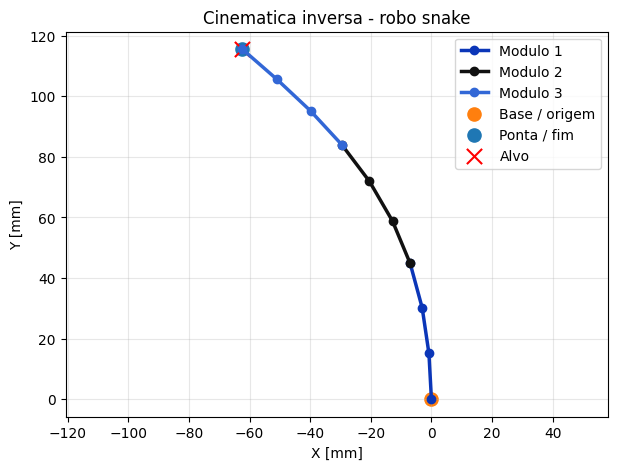

In [9]:
cores = ["#0b36b8", "#111111", "#3267d6"]

fig, ax = plt.subplots(figsize=(7, 5))

for modulo in range(n_modulos):
    inicio = modulo * juntas_por_modulo
    fim = inicio + juntas_por_modulo
    trecho = pos_solucao[inicio:fim + 1]
    ax.plot(
        trecho[:, 0] * 1000,
        trecho[:, 1] * 1000,
        "-o",
        linewidth=2.5,
        color=cores[modulo],
        label=f"Modulo {modulo + 1}",
    )

ax.scatter([0], [0], s=90, color="#ff7f0e", label="Base / origem")
ax.scatter([ponta_solucao_mm[0]], [ponta_solucao_mm[1]], s=90, color="#1f77b4", label="Ponta / fim")
ax.scatter([alvo_mm[0]], [alvo_mm[1]], marker="x", s=120, color="red", label="Alvo")
ax.set_title("Cinematica inversa - robo snake")
ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## 9. Convergencia do erro

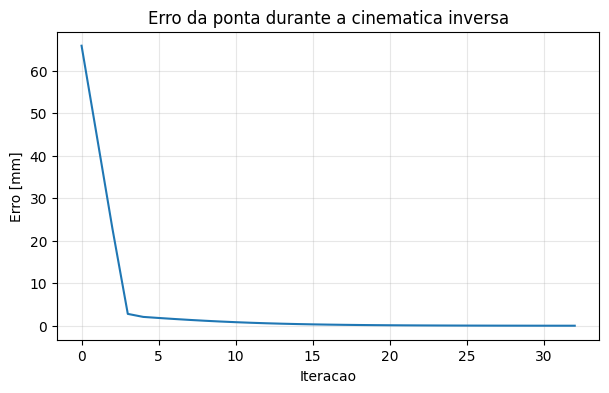

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.array(erros) * 1000)
ax.set_title("Erro da ponta durante a cinematica inversa")
ax.set_xlabel("Iteracao")
ax.set_ylabel("Erro [mm]")
ax.grid(True, alpha=0.3)
plt.show()


## Resumo

A cinematica inversa foi resolvida numericamente:

1. foi definido um alvo para a ponta;
2. foi escolhido um chute inicial de angulos;
3. a cinematica direta calculou a posicao atual;
4. o Jacobiano indicou como corrigir os angulos;
5. o processo foi repetido ate a ponta chegar proxima ao alvo.

Como o robo tem 9 juntas, essa nao e a unica solucao possivel. Ela e apenas uma configuracao valida encontrada pelo metodo numerico.
